# 03 — HITS: implementacija i validacija

Treća sveska u nizu (`01` → `07`). Implementiramo **HITS** [1, 2] (Hyperlink-Induced Topic Search) iz nule, primenjenu **globalno** nad celim grafom (bez query-specifičnog root/base seta — videti obrazloženje u `README.md`).

Posebno testiramo hipotezu **H2** iz `README.md`: pošto je HITS matematički power-iteracija ka glavnom sopstvenom vektoru (dominantnom singularnom vektoru matrice susedstva), na grafu koji nije jedna povezana komponenta (u `01_priprema_i_analiza_podataka.ipynb` smo utvrdili da web-Stanford ima 365 slabo povezanih komponenti) očekujemo da HITS "ugasi" na skor ≈ 0 velik broj čvorova van dominantne komponente.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
SLIKE_DIR = PROJECT_ROOT / "slike"
SLIKE_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Snima figuru u slike/<name> (koriste se kasnije u dokumentaciji/prezentaciji)."""
    path = SLIKE_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Sačuvano: {path.relative_to(PROJECT_ROOT)}")


# --- Ista paleta/stil kao u prethodnim sveskama (konzistentno kroz projekat) ---
PALETTE = {
    "pagerank": "#2a78d6", "hits": "#eb6834", "salsa": "#1baf7a", "baseline": "#eda100",
}
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
})

# --- Učitavanje grafa obrađenog u 01_priprema_i_analiza_podataka.ipynb ---
A = sp.load_npz(DATA_PROCESSED / "web-stanford_adjacency.npz")
nodes = np.load(DATA_PROCESSED / "web-stanford_nodes.npy")
n = A.shape[0]
print(f"Graf učitan: {n:,} čvorova, {A.nnz:,} grana")

Graf učitan: 281,903 čvorova, 2,312,497 grana


## 1. Teorija — HITS (uzajamno pojačavanje)

HITS računa **autoritet** skor $A(u)$ (koliko je $u$ dobra referenca na temu) i **hub** skor $H(u)$ (koliko $u$ dobro upućuje na autoritativne stranice), iterativnim "uzajamnim pojačavanjem" [1, 2]:

$$A'(v) = \sum_{(u,v) \in E} H(u) \qquad\qquad H'(u) = \sum_{(u,v) \in E} A(v)$$

nakon čega se oba vektora normalizuju na jediničnu $L_2$ normu. U matričnom obliku (M = matrica susedstva): $a' = M^T h$, $h' = M a$ — ovo je tačno power-iteracija ka dominantnim singularnim vektorima matrice $M$ (ekvivalentno: $a$ konvergira ka glavnom sopstvenom vektoru $M^T M$, $h$ ka glavnom sopstvenom vektoru $M M^T$).

**Zašto je ovo bitno za H2:** power-iteracija po konstrukciji konvergira SAMO ka pravcu koji odgovara najvećoj sopstvenoj vrednosti. Ako graf ima više nezavisnih (nepovezanih) komponenti, svaka bi "sama za sebe" imala svoj dominantan pravac — ali globalna iteracija bira samo jedan, onaj sa najvećom sopstvenom vrednošću u celom grafu, i sve ostale komponente asimptotski dobijaju skor → 0. Ovo je suštinska razlika u odnosu na PageRank, koji zahvaljujući teleportaciji garantuje da svaki čvor dobije nenula skor.

In [2]:
def hits(A, tol=1e-12, max_iter=500):
    """HITS preko uzajamnog pojačavanja (power-iteracija) nad sparse matricom A.

    Vraća (h, a, history, broj_iteracija) - h = hub skorovi, a = authority skorovi,
    history = L1 promena po iteraciji (hub + authority kombinovano).
    """
    n = A.shape[0]
    h = np.full(n, 1.0 / np.sqrt(n))
    a = np.full(n, 1.0 / np.sqrt(n))
    At = A.T.tocsr()

    history = []
    for it in range(1, max_iter + 1):
        a_new = At @ h
        h_new = A @ a
        a_new = a_new / np.linalg.norm(a_new)
        h_new = h_new / np.linalg.norm(h_new)

        diff = float(np.abs(a_new - a).sum() + np.abs(h_new - h).sum())
        history.append(diff)
        a, h = a_new, h_new
        if diff < tol:
            break
    return h, a, history, it

## 2. Pokretanje algoritma

In [3]:
hits_hub, hits_authority, hits_history, hits_iters = hits(A)

print(f"Konvergirao nakon {hits_iters} iteracija")
print(f"Kontrola: ||h||_2 = {np.linalg.norm(hits_hub):.6f}, ||a||_2 = {np.linalg.norm(hits_authority):.6f}  (oba treba da budu ≈ 1.0)")

Konvergirao nakon 97 iteracija
Kontrola: ||h||_2 = 1.000000, ||a||_2 = 1.000000  (oba treba da budu ≈ 1.0)


Sačuvano: slike\f3_hits_konvergencija.png


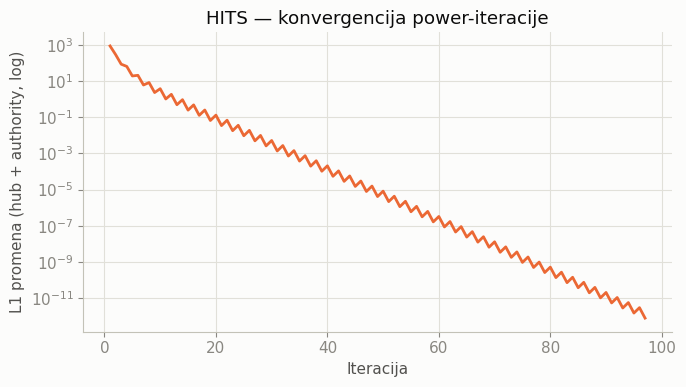

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(hits_history) + 1), hits_history, color=PALETTE["hits"], linewidth=2)
ax.set_yscale("log")
ax.set_xlabel("Iteracija")
ax.set_ylabel("L1 promena (hub + authority, log)")
ax.set_title("HITS — konvergencija power-iteracije")
fig.tight_layout()
save_fig(fig, "f3_hits_konvergencija.png")
plt.show()

## 3. Test hipoteze H2 — "gašenje" čvorova van dominantne komponente

Brojimo koliko čvorova ima praktično nula skor (< 10⁻¹⁰) — i koliko ima *strogo* nula skor (numerički underflow na 0.0), za hub i authority posebno.

In [5]:
NEGLIGIBLE = 1e-10

n_zero_a_exact = int((hits_authority == 0.0).sum())
n_zero_h_exact = int((hits_hub == 0.0).sum())
n_negligible_a = int((hits_authority < NEGLIGIBLE).sum())
n_negligible_h = int((hits_hub < NEGLIGIBLE).sum())

print(f"Authority: strogo 0.0 kod {n_zero_a_exact:,} / {n:,} čvorova ({n_zero_a_exact/n:.1%})")
print(f"Authority: < 1e-10 kod    {n_negligible_a:,} / {n:,} čvorova ({n_negligible_a/n:.1%})")
print(f"Hub:       strogo 0.0 kod {n_zero_h_exact:,} / {n:,} čvorova ({n_zero_h_exact/n:.1%})")
print(f"Hub:       < 1e-10 kod    {n_negligible_h:,} / {n:,} čvorova ({n_negligible_h/n:.1%})")

Authority: strogo 0.0 kod 20,315 / 281,903 čvorova (7.2%)


Authority: < 1e-10 kod    180,009 / 281,903 čvorova (63.9%)
Hub:       strogo 0.0 kod 172 / 281,903 čvorova (0.1%)
Hub:       < 1e-10 kod    134,483 / 281,903 čvorova (47.7%)


Sačuvano: slike\f3_hits_ugaseni_cvorovi.png


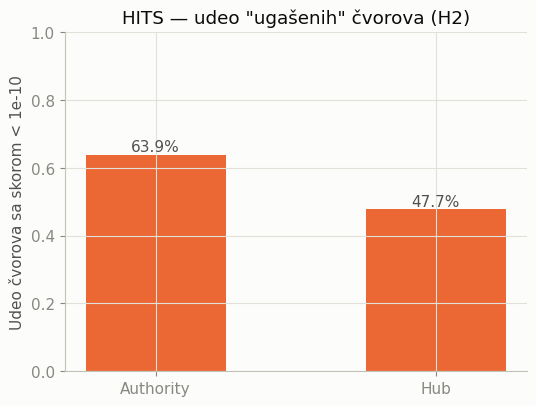

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
categories = ["Authority", "Hub"]
fractions = [n_negligible_a / n, n_negligible_h / n]
ax.bar(categories, fractions, color=PALETTE["hits"], width=0.5)
for i, f in enumerate(fractions):
    ax.text(i, f + 0.01, f"{f:.1%}", ha="center", color=INK_2)
ax.set_ylabel("Udeo čvorova sa skorom < 1e-10")
ax.set_ylim(0, 1)
ax.set_title("HITS — udeo \"ugašenih\" čvorova (H2)")
fig.tight_layout()
save_fig(fig, "f3_hits_ugaseni_cvorovi.png")
plt.show()

## 4. Top-10 čvorova po hub i authority skoru

In [7]:
top10_a_idx = np.argsort(-hits_authority)[:10]
top10_h_idx = np.argsort(-hits_hub)[:10]

top10_hits_df = pd.DataFrame({
    "rang": range(1, 11),
    "authority_node_id": nodes[top10_a_idx], "authority_skor": hits_authority[top10_a_idx],
    "hub_node_id": nodes[top10_h_idx], "hub_skor": hits_hub[top10_h_idx],
})
top10_hits_df

,rang,authority_node_id,authority_skor,hub_node_id,hub_skor
0,1,226411,0.348585,97968,0.007256
1,2,234704,0.317136,193259,0.007256
2,3,105607,0.312541,275047,0.007255
3,4,198090,0.311606,102208,0.007255
4,5,81435,0.311599,151695,0.007254
5,6,214128,0.311589,31061,0.007254
6,7,167295,0.311482,194656,0.007254
7,8,38342,0.311445,95769,0.007254
8,9,245659,0.311383,272199,0.007253
9,10,34573,0.311322,95705,0.007253


Sačuvano: slike\f3_hits_top10.png


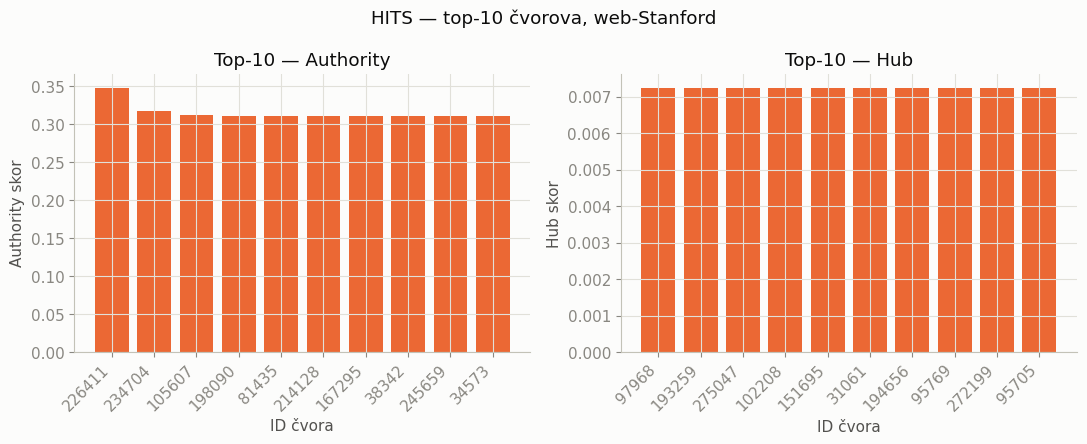

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar([str(v) for v in nodes[top10_a_idx]], hits_authority[top10_a_idx], color=PALETTE["hits"])
axes[0].set_title("Top-10 — Authority")
axes[0].set_xlabel("ID čvora")
axes[0].set_ylabel("Authority skor")

axes[1].bar([str(v) for v in nodes[top10_h_idx]], hits_hub[top10_h_idx], color=PALETTE["hits"])
axes[1].set_title("Top-10 — Hub")
axes[1].set_xlabel("ID čvora")
axes[1].set_ylabel("Hub skor")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

fig.suptitle("HITS — top-10 čvorova, web-Stanford")
fig.tight_layout()
save_fig(fig, "f3_hits_top10.png")
plt.show()

## 5. Validacija — poređenje sa `networkx.hits`

**Napomena o normalizaciji:** naša implementacija normalizuje $h$ i $a$ na jediničnu $L_2$ normu (kako je definisano u [1, 2] i u referentnom Najork radu, sekcija 5.2), dok `networkx.hits` po default-u normalizuje tako da zbir ($L_1$) bude 1. Ovo je samo razlika u konvenciji skaliranja — **rangiranje** (redosled čvorova) treba da bude identično, pa validaciju radimo preko rang-korelacije, ne preko sirovih vrednosti skorova.

In [9]:
import networkx as nx
from scipy.stats import spearmanr

G_nx = nx.from_scipy_sparse_array(A, create_using=nx.DiGraph)
hub_nx_dict, auth_nx_dict = nx.hits(G_nx, max_iter=500, tol=1e-12)
hub_nx = np.array([hub_nx_dict[i] for i in range(n)])
auth_nx = np.array([auth_nx_dict[i] for i in range(n)])

rho_a_full, _ = spearmanr(hits_authority, auth_nx)
rho_h_full, _ = spearmanr(hits_hub, hub_nx)

# korelacija ograničena na čvorove sa "stvarnim" (non-negligible) skorom - vidi objašnjenje ispod
mask_a = hits_authority > NEGLIGIBLE
mask_h = hits_hub > NEGLIGIBLE
rho_a_masked, _ = spearmanr(hits_authority[mask_a], auth_nx[mask_a])
rho_h_masked, _ = spearmanr(hits_hub[mask_h], hub_nx[mask_h])

top10_a_overlap = len(set(np.argsort(-auth_nx)[:10]) & set(top10_a_idx)) / 10
top10_h_overlap = len(set(np.argsort(-hub_nx)[:10]) & set(top10_h_idx)) / 10

print(f"Spearman authority (svi čvorovi):            {rho_a_full:.6f}")
print(f"Spearman authority (samo non-negligible, {mask_a.sum():,}): {rho_a_masked:.6f}")
print(f"Spearman hub (svi čvorovi):                  {rho_h_full:.6f}")
print(f"Spearman hub (samo non-negligible, {mask_h.sum():,}):       {rho_h_masked:.6f}")
print(f"Preklapanje top-10 authority: {top10_a_overlap:.0%}   Preklapanje top-10 hub: {top10_h_overlap:.0%}")

Spearman authority (svi čvorovi):            0.952681
Spearman authority (samo non-negligible, 101,894): 0.999984
Spearman hub (svi čvorovi):                  0.977928
Spearman hub (samo non-negligible, 147,420):       0.999997
Preklapanje top-10 authority: 100%   Preklapanje top-10 hub: 100%


**Tumačenje.** Korelacija računata nad *svim* čvorovima je vidno niža od korelacije nad non-negligible podskupom. Razlog nije greška u implementaciji: kada je skor "praktično nula" (ispod granice numeričke preciznosti), sitne razlike u putu konvergencije dve nezavisne implementacije (drugačiji redosled operacija, drugačiji broj iteracija) proizvode nasumičan redosled među tim nula-vrednostima — bez ikakvog stvarnog značenja. Zato je Spearman korelacija ograničena na non-negligible skorove (i 100% poklapanje top-10 skupova) prava mera validnosti implementacije.

## 6. Čuvanje rezultata

In [10]:
np.save(DATA_PROCESSED / "hits_hub_scores.npy", hits_hub)
np.save(DATA_PROCESSED / "hits_authority_scores.npy", hits_authority)
print(f"Sačuvano: {(DATA_PROCESSED / 'hits_hub_scores.npy').relative_to(PROJECT_ROOT)}")
print(f"Sačuvano: {(DATA_PROCESSED / 'hits_authority_scores.npy').relative_to(PROJECT_ROOT)}")

Sačuvano: data\processed\hits_hub_scores.npy
Sačuvano: data\processed\hits_authority_scores.npy


## Zaključci — Faza 3

**Implementacija je validna.** HITS konvergira nakon **97 iteracija** (tol = 10⁻¹²), ||h||₂ = ||a||₂ = 1,000000 kao što treba. Rang-korelacija sa `networkx.hits`, ograničena na skorove koji nisu numerički zanemarljivi, je **0,999984** (authority) i **0,999997** (hub), sa **100% preklapanjem top-10** skupova u oba slučaja — implementacija je potvrđena.

**Lep sanity-check koji povezuje sveske:** broj čvorova sa *strogo* nula authority skorom (**20.315**) tačno odgovara broju čvorova sa in-degree = 0 iz `01_priprema_i_analiza_podataka.ipynb` — matematički očekivano, jer $A'(v)=\\sum H(u)$ preko prethodnika nužno daje 0 ako prethodnika nema. Isto važi za hub skor i out-degree = 0 (**172** čvora u oba slučaja).

**H2 je potvrđena, i mnogo dramatičnije nego što je hipoteza pretpostavljala.** Van tih trivijalnih (strukturnih) nula, HITS-ova power-iteracija dodatno "ugasi" (skor < 10⁻¹⁰) još:
- **63,9%** čvorova po authority skoru (naspram 7,2% trivijalnih nula — dakle dodatnih ≈56,7% "ugašeno" isključivo zbog dominacije glavnog sopstvenog vektora),
- **47,7%** čvorova po hub skoru (naspram 0,1% trivijalnih — dodatnih ≈47,6%).

Ovo je direktna, merljiva posledica onoga što je teorija predvidela u sekciji 1 ove sveske: HITS bira samo JEDAN dominantan pravac u celom grafu, dok PageRank (Faza 2) svakom čvoru garantuje nenula skor kroz teleportaciju.

**Nagoveštaj TKC efekta u samim podacima.** Top-10 hub skorova su međusobno skoro identični (0,007256 → 0,007253, vidi `f3_hits_top10.png`) — to je signatura da HITS-ov hub-rang dominira jedna gusto međusobno povezana grupa stranica (nalik "tightly knit community" efektu iz Lempel-Moran [3]), a ne postepena gradacija kvaliteta. Authority top-10 je malo razuđeniji (0,349 → 0,311), ali i tu je pad nakon prvog mesta nagao pa zatim vrlo ravan.

**Sledeći korak:** `04_salsa.ipynb` — implementacija i validacija SALSA-e. Prema H1, očekujemo da SALSA-in autoritet bude znatno bliži in-degree rangiranju, i da (zbog stohastičke formulacije, umesto power-iteracije ka jednom dominantnom pravcu) ne pokazuje ovoliko drastično "gašenje" čvorova van dominantne komponente.
